# Estimating Delta: Pathwise Derivatives vs. the Likelihood Ratio Method

Let $\theta\mapsto Y(\theta)$ be the discounted payoff of a derivative security as a function of a
parameter $\theta$ (here $\theta=S(0)$), and let $\alpha(\theta) = \mathrm E[Y(\theta)]$ be the
quantity to be differentiated. Two structurally different unbiased estimators of $\alpha'(\theta)$ are
developed below; both hinge on an interchange of a limit (or integral) with an expectation, and the
two methods differ precisely in *which* interchange they require — which is why they succeed or fail
on different payoffs.

## The pathwise method

Fix a probability space $(\Omega,\mathcal F,\mathrm P)$ and a random function
$\{Y(\theta,\omega),\theta\in\Theta\}$, $\Theta\subseteq\mathbb R$ an interval — i.e. for each
$\omega$, $\theta\mapsto Y(\theta,\omega)$ is a (random) function, and the *pathwise derivative* is

$$
Y'(\theta) = \lim_{h\to0}\frac{Y(\theta+h)-Y(\theta)}{h},
$$

understood to exist with probability 1. The estimator $Y'(\theta)$ is unbiased for $\alpha'(\theta)$
iff the interchange
$\mathrm E\big[\lim_{h\to0} h^{-1}(Y(\theta+h)-Y(\theta))\big] = \lim_{h\to0}h^{-1}\mathrm E[Y(\theta+h)-Y(\theta)]$
is valid — equivalently (a necessary and sufficient condition), iff the difference quotients are
**uniformly integrable**. Writing $Y(\theta)=f(X(\theta))$ for a vector $X(\theta)$ of underlying-asset
values, sufficient conditions that are easy to check in practice are:

- **(A1)–(A2)** $X_i'(\theta)$ exists a.s. and $\mathrm P(X(\theta)\in D_f)=1$ for every $\theta$
  ($D_f$ = the differentiability set of $f$);
- **(A3)** $f$ is **Lipschitz**: $|f(x)-f(y)|\le k_f\|x-y\|$;
- **(A4)** $X(\theta)$ is Lipschitz in $\theta$ with an integrable Lipschitz constant.

(A3)+(A4) make $Y(\theta)$ a.s. Lipschitz in $\theta$, which is enough to justify the interchange
(Broadie & Glasserman). A standard call, an Asian call, and a lookback all satisfy (A3), because `max`
and sums/averages of Lipschitz functions are Lipschitz. **An indicator function is not Lipschitz** —
this single fact is the entire reason the method fails on digital and barrier payoffs below.

## The likelihood ratio (score function) method

Suppose instead that $X$ has a density $g_\theta$ depending smoothly on $\theta$, and
$\alpha(\theta)=\mathrm E_\theta[f(X)] = \int f(x)g_\theta(x)\,\mathrm dx$. If differentiation may be
passed inside the integral,

$$
\alpha'(\theta) = \int f(x)\,\dot g_\theta(x)\,\mathrm dx
= \int f(x)\,\frac{\dot g_\theta(x)}{g_\theta(x)}\,g_\theta(x)\,\mathrm dx
= \mathrm E_\theta\Big[f(X)\,\frac{\dot g_\theta(X)}{g_\theta(X)}\Big],
$$

so $f(X)\cdot\dot g_\theta(X)/g_\theta(X)$ is unbiased for $\alpha'(\theta)$; the term
$\dot g_\theta/g_\theta = \mathrm d\log g_\theta/\mathrm d\theta$ is the **score function**. Crucially,
this interchange only requires smoothness of the *density* in $\theta$ — a property of the model, not
of the payoff $f$ — so **the method places no regularity requirement on $f$ at all**, and applies
verbatim to discontinuous payoffs such as the digital option.

The same random variable can often be represented either as a deterministic function of $\theta$ and a
fixed random seed (pathwise view) or as a draw from a $\theta$-indexed density (likelihood-ratio view);
which representation is used is a matter of choice, not a property of the model itself.


In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

r = 0.05
sigma = 0.30
S0 = 50.0
T = 0.25
K = 50.0

def bs_d1_d2(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_call_delta(S0, K, r, sigma, T):
    d1, _ = bs_d1_d2(S0, K, r, sigma, T)
    return norm.cdf(d1)

def digital_call_delta_closed_form(S0, K, r, sigma, T):
    # Price = e^{-rT} P(S_T > K) = e^{-rT} Phi(d2); differentiate w.r.t. S0.
    _, d2 = bs_d1_d2(S0, K, r, sigma, T)
    return np.exp(-r * T) * norm.pdf(d2) / (S0 * sigma * np.sqrt(T))

print(f"Closed-form BS call delta      : {bs_call_delta(S0, K, r, sigma, T):.6f}")
print(f"Closed-form digital call delta : {digital_call_delta_closed_form(S0, K, r, sigma, T):.6f}")


Closed-form BS call delta      : 0.562903
Closed-form digital call delta : 0.052530


## Case (a): standard European call

With $S(T) = S(0)\exp((r-\tfrac12\sigma^2)T+\sigma\sqrt T Z)$, $Z\sim N(0,1)$, the chain rule gives

$$
\frac{\mathrm dY}{\mathrm dS(0)}
= \underbrace{e^{-rT}\mathbf 1\{S(T)>K\}}_{\mathrm dY/\mathrm dS(T),\ \text{a.s. defined}}\cdot
\underbrace{\frac{S(T)}{S(0)}}_{\mathrm dS(T)/\mathrm dS(0)}
= e^{-rT}\,\mathbf 1\{S(T)>K\}\,\frac{S(T)}{S(0)}
$$

(the derivative of $\max(0,x-K)$ fails only at $x=K$, an event of probability 0). This is the
**pathwise** estimator, exactly matching (A1)–(A4): the payoff is Lipschitz in $S(T)$, and $S(T)$ is
Lipschitz (indeed linear) in $S(0)$.

For the **likelihood ratio** estimator, view $S(0)$ as a location parameter of the lognormal density of
$S(T)$: $g(x) = \frac{1}{x\sigma\sqrt T}\varphi(\zeta(x))$, $\zeta(x) = (\log(x/S(0))-(r-\tfrac12\sigma^2)T)/(\sigma\sqrt T)$.
Differentiating $\log g$ with respect to $S(0)$ and evaluating at the simulated $S(T)$ (where
$\zeta(S(T))=Z$) gives the score $Z/(S(0)\sigma\sqrt T)$, so

$$
\frac{\mathrm dY}{\mathrm dS(0)} = e^{-rT}\,(S(T)-K)^+\cdot\frac{Z}{S(0)\sigma\sqrt T}.
$$


In [2]:
def simulate_terminal(n_paths, S0, r, sigma, T, rng):
    Z = rng.standard_normal(n_paths)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    return S_T, Z

n_paths = 2_000_000
S_T, Z = simulate_terminal(n_paths, S0, r, sigma, T, rng)
disc = np.exp(-r * T)

# --- Standard call ---
call_payoff = disc * np.maximum(S_T - K, 0.0)
pathwise_call = disc * (S_T > K) * (S_T / S0)
lr_score = Z / (S0 * sigma * np.sqrt(T))
lr_call = call_payoff * lr_score

closed_delta_call = bs_call_delta(S0, K, r, sigma, T)
print("Standard European call, delta:")
print(f"  closed form      : {closed_delta_call:.6f}")
print(f"  pathwise estimate: {pathwise_call.mean():.6f}  (s.e. {pathwise_call.std(ddof=1)/np.sqrt(n_paths):.6f})")
print(f"  LR estimate      : {lr_call.mean():.6f}  (s.e. {lr_call.std(ddof=1)/np.sqrt(n_paths):.6f})")


Standard European call, delta:
  closed form      : 0.562903
  pathwise estimate: 0.563339  (s.e. 0.000399)
  LR estimate      : 0.562326  (s.e. 0.000935)


## Case (b): digital option — where the pathwise method fails

For $Y=e^{-rT}\mathbf 1\{S(T)>K\}$, the map $x\mapsto\mathbf 1\{x>K\}$ is differentiable everywhere
except at $x=K$ (probability 0), so $Y$ *is* a.s. differentiable in $S(0)$ — but its derivative is $0$
wherever it exists, since the indicator is locally constant away from the jump. Hence

$$
0 = \mathrm E\Big[\frac{\mathrm dY}{\mathrm dS(0)}\Big] \neq \frac{\mathrm d}{\mathrm dS(0)}\mathrm E[Y],
$$

and the interchange (A3) fails outright: the indicator is **not Lipschitz**, so there is no
integrable bound on the difference quotients and the necessary uniform-integrability condition breaks
down. The pathwise derivative sees only the a.s. local constancy of $Y$ and is entirely blind to the
positive-probability event that a change in $S(0)$ moves $S(T)$ across the strike — which is exactly
the mechanism driving the true sensitivity of $\mathrm E[Y]$.

The likelihood ratio estimator is unaffected, since it differentiates the (smooth) density of $S(T)$
rather than the (discontinuous) payoff:

$$
\frac{\mathrm dY}{\mathrm dS(0)} = e^{-rT}\,\mathbf 1\{S(T)>K\}\cdot\frac{Z}{S(0)\sigma\sqrt T}.
$$


In [3]:
digital_payoff = disc * (S_T > K).astype(float)
pathwise_digital = np.zeros(n_paths)  # identically zero a.s., as derived above
lr_digital = digital_payoff * lr_score

closed_delta_digital = digital_call_delta_closed_form(S0, K, r, sigma, T)
print("Digital (cash-or-nothing) call, delta:")
print(f"  closed form      : {closed_delta_digital:.6f}")
print(f"  pathwise estimate: {pathwise_digital.mean():.6f}  <- identically 0, uninformative by construction")
print(f"  LR estimate      : {lr_digital.mean():.6f}  (s.e. {lr_digital.std(ddof=1)/np.sqrt(n_paths):.6f})")


Digital (cash-or-nothing) call, delta:
  closed form      : 0.052530


  pathwise estimate: 0.000000  <- identically 0, uninformative by construction
  LR estimate      : 0.052505  (s.e. 0.000054)


## Case (c): path-dependent (arithmetic Asian) delta

Let $Y=e^{-rT}(\bar S-K)^+$, $\bar S=\frac1m\sum_{i=1}^m S(t_i)$. Since
$\mathrm dS(t_i)/\mathrm dS(0) = S(t_i)/S(0)$ for every $i$ (each $S(t_i)$ is linear in $S(0)$ along a
fixed path), the chain rule gives the (A3)-compliant, Lipschitz-composed-with-Lipschitz pathwise
estimator

$$
\frac{\mathrm dY}{\mathrm dS(0)} = e^{-rT}\,\mathbf 1\{\bar S>K\}\cdot\frac{\bar S}{S(0)} .
$$

For the likelihood ratio estimator we must be more careful than in the terminal-value case: the
natural object with a $S(0)$-dependent density is the *vector* $X=(\log S(t_1),\dots,\log S(t_m))$,
which is multivariate Gaussian with mean $\mu(\eta) = \eta\mathbf 1 + c$ (a common location shift in
$\eta=\log S(0)$, since every $\log S(t_i)$ contains $\log S(0)$ additively) and a fixed covariance
$\Sigma_{ij}=\sigma^2\min(t_i,t_j)$ that does **not** depend on $S(0)$. For a Gaussian location family
the score is $\Sigma^{-1}(x-\mu(\eta))$, so the score for the *common* shift $\eta$ is
$v^\top(x-\mu(\eta))$ with $v=\Sigma^{-1}\mathbf 1$ (equivalently, $v$ solves $\Sigma v=\mathbf 1$ — a
single generalized-least-squares solve), and $\mathrm d/\mathrm dS(0) = S(0)^{-1}\,\mathrm d/\mathrm d\eta$:

$$
\frac{\mathrm dY}{\mathrm dS(0)} = \frac{Y}{S(0)}\, v^\top\big(X-\mu(\eta)\big),\qquad \Sigma v=\mathbf 1 .
$$

(Representing the path instead through its independent driving increments — as in the terminal-value
case — makes $S(0)$ a purely deterministic, non-random shift and collapses the likelihood-ratio
construction back into the pathwise one; the two methods are genuinely equivalent representational
choices, not different models.)


In [4]:
m = 13
t_grid = np.linspace(T / m, T, m)
dt = np.diff(np.concatenate(([0.0], t_grid)))

n_paths_asian = 500_000
Zm = rng.standard_normal((n_paths_asian, m))
increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Zm
log_S_path = np.log(S0) + np.cumsum(increments, axis=1)
S_path = np.exp(log_S_path)

S_bar = S_path.mean(axis=1)
asian_payoff = disc * np.maximum(S_bar - K, 0.0)

pathwise_asian = disc * (S_bar > K) * (S_bar / S0)

# Likelihood-ratio score for the common location shift eta = log(S0):
Sigma = sigma**2 * np.minimum.outer(t_grid, t_grid)
v = np.linalg.solve(Sigma, np.ones(m))
mu = np.log(S0) + (r - 0.5 * sigma**2) * t_grid          # mean of log S(t_i) at current S0
centered = log_S_path - mu
score_eta = centered @ v                                  # v^T (X - mu(eta)), score w.r.t. eta = log S0
lr_asian = asian_payoff * score_eta / S0                  # chain rule: d/dS0 = (1/S0) d/d(eta)

# High-accuracy central finite-difference reference (common random numbers)
cum_increments = np.cumsum(increments, axis=1)

def asian_price(S0_):
    # rebuild the path multiplicatively from the SAME increments/Z, rescaling only the S0 factor:
    S_path_ = S0_ * np.exp(cum_increments)
    S_bar_ = S_path_.mean(axis=1)
    return (disc * np.maximum(S_bar_ - K, 0.0)).mean()

h = 1e-3
fd_delta_asian = (asian_price(S0 + h) - asian_price(S0 - h)) / (2 * h)

print("Arithmetic Asian call, delta:")
print(f"  pathwise estimate         : {pathwise_asian.mean():.6f}  (s.e. {pathwise_asian.std(ddof=1)/np.sqrt(n_paths_asian):.6f})")
print(f"  likelihood-ratio estimate : {lr_asian.mean():.6f}  (s.e. {lr_asian.std(ddof=1)/np.sqrt(n_paths_asian):.6f})")
print(f"  central finite-difference reference (common random numbers, h={h}): {fd_delta_asian:.6f}")


Arithmetic Asian call, delta:
  pathwise estimate         : 0.541952  (s.e. 0.000756)
  likelihood-ratio estimate : 0.541043  (s.e. 0.002780)
  central finite-difference reference (common random numbers, h=0.001): 0.541952


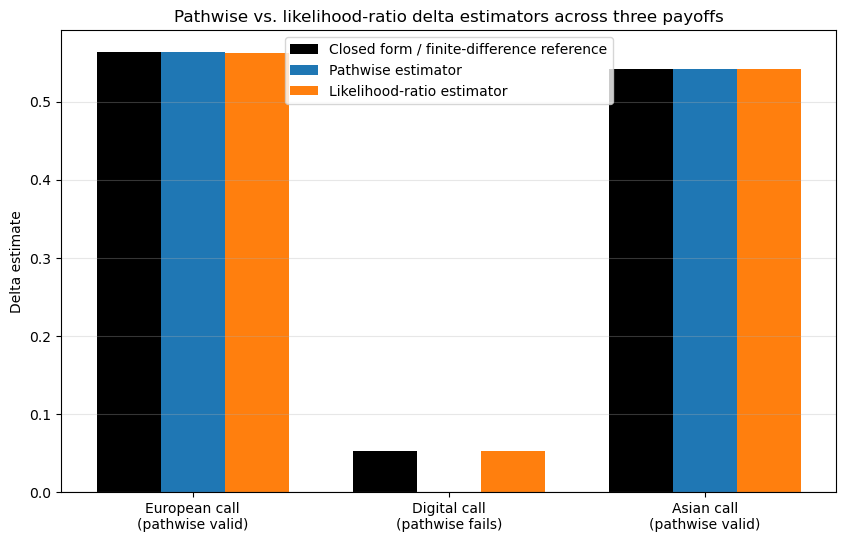

In [5]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["European call\n(pathwise valid)", "Digital call\n(pathwise fails)", "Asian call\n(pathwise valid)"]
closed = [closed_delta_call, closed_delta_digital, fd_delta_asian]
pathwise_vals = [pathwise_call.mean(), pathwise_digital.mean(), pathwise_asian.mean()]
lr_vals = [lr_call.mean(), lr_digital.mean(), lr_asian.mean()]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, closed, width, label="Closed form / finite-difference reference", color="black")
ax.bar(x, pathwise_vals, width, label="Pathwise estimator", color="tab:blue")
ax.bar(x + width, lr_vals, width, label="Likelihood-ratio estimator", color="tab:orange")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Delta estimate")
ax.set_title("Pathwise vs. likelihood-ratio delta estimators across three payoffs")
ax.axhline(0, color="0.5", linewidth=0.8)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.savefig("greeks_delta_estimator_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

| Payoff | Pathwise valid? | Pathwise result | LR result | Closed form |
|---|---|---|---|---|
| European call | Yes (Lipschitz) | matches closed form | matches closed form | $\Phi(d_1)$ |
| Digital call | **No** (indicator not Lipschitz) | **identically 0, uninformative** | matches closed form | $e^{-rT}\varphi(d_2)/(S_0\sigma\sqrt T)$ |
| Arithmetic Asian call | Yes (Lipschitz, path-linear in $S(0)$) | matches LR and finite-difference reference | matches pathwise and finite-difference reference | no closed form |

The digital option is the case that matters: it is not a pathological edge case but the generic
signature of any payoff with a jump (digitals, barriers, and the *second* derivative — the gamma — of
a standard call, whose first derivative is itself a digital-shaped indicator). Whenever a discontinuous
payoff is in play, the likelihood ratio method is the only one of the two that remains valid without
modification (smoothing the payoff, or conditioning, are the usual pathwise-side remedies, and are not
pursued here).
